In [2]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

db_path = r"C:\Users\rs38129\Desktop\BI\retail-operations-analytics\Data\retail_olist.db"
connection=sqlite3.connect(db_path)
print("Connected")

Connected


In [3]:
monthly_revenue = pd.read_sql("""
    SELECT
        order_year_month,
        order_year,
        order_month,
        COUNT(DISTINCT order_id)             AS total_orders,
        ROUND(SUM(price), 2)                 AS product_revenue,
        ROUND(SUM(freight_value), 2)         AS freight_revenue,
        ROUND(SUM(price + freight_value), 2) AS total_revenue
    FROM master_orders
    GROUP BY order_year_month, order_year, order_month
    ORDER BY order_year_month
""", connection)

print(monthly_revenue.shape)
monthly_revenue.head(10)

(22, 7)


,order_year_month,order_year,order_month,total_orders,product_revenue,freight_revenue,total_revenue
0,2016-10,2016,10,265,40325.11,6165.55,46490.66
1,2016-12,2016,12,1,10.90,8.72,19.62
2,2017-01,2017,1,750,111798.36,15684.01,127482.37
3,2017-02,2017,2,1653,234223.40,37015.92,271239.32
4,2017-03,2017,3,2546,359198.85,55132.10,414330.95
5,2017-04,2017,4,2303,340669.68,50142.72,390812.40
6,2017-05,2017,5,3545,489159.25,77498.15,566657.40
7,2017-06,2017,6,3135,421923.37,68127.00,490050.37
8,2017-07,2017,7,3872,481604.52,84694.56,566299.08
9,2017-08,2017,8,4193,554699.70,91132.66,645832.36


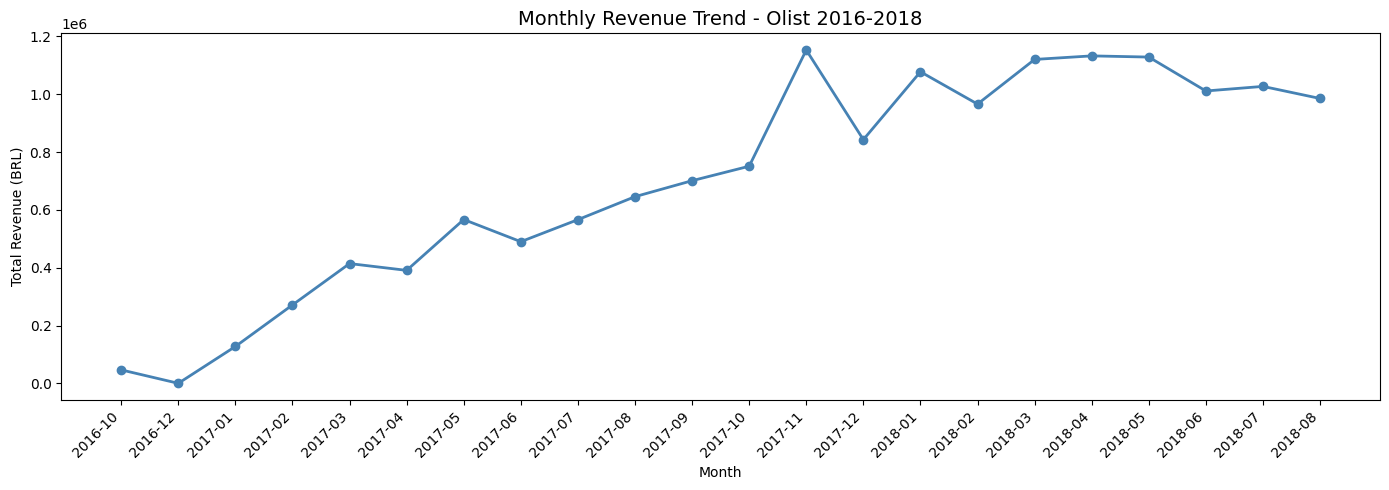

Chart saved to exports/


In [4]:
plt.figure(figsize=(14, 5))
plt.plot(monthly_revenue['order_year_month'], 
         monthly_revenue['total_revenue'], 
         marker='o', color='steelblue', linewidth=2)

plt.title('Monthly Revenue Trend - Olist 2016-2018', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Total Revenue (BRL)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('C:\\Users\\rs38129\\Desktop\\BI\\retail-operations-analytics\\Exports\\monthly_revenue_trend.png', dpi=150)
plt.show()
print("Chart saved to exports/")

## Key Insight: Revenue Trend
- Clear upward growth trajectory from early 2017 through 2018
- November 2017 spike aligns with Black Friday — Brazil's largest 
  shopping event, confirming seasonality in the business
- 2016 data is sparse (Olist launched mid-2016), so YoY comparisons 
  should focus on 2017 vs 2018
- All revenue figures in BRL (Brazilian Real)

In [5]:
yearly_summary = pd.read_sql("""
    SELECT
        order_year,
        COUNT(DISTINCT order_id)             AS total_orders,
        COUNT(DISTINCT customer_unique_id)   AS unique_customers,
        ROUND(SUM(price + freight_value), 2) AS total_revenue,
        ROUND(AVG(price + freight_value), 2) AS avg_order_value
    FROM master_orders
    GROUP BY order_year
    ORDER BY order_year
""", connection)

yearly_summary

,order_year,total_orders,unique_customers,total_revenue,avg_order_value
0,2016,266,263,46510.28,148.12
1,2017,43426,42134,6921206.41,139.67
2,2018,52777,51606,8450534.68,140.10


In [6]:
revenue_2017 = yearly_summary.loc[yearly_summary['order_year']==2017, 'total_revenue'].values[0]
revenue_2018 = yearly_summary.loc[yearly_summary['order_year']==2018, 'total_revenue'].values[0]

orders_2017 = yearly_summary.loc[yearly_summary['order_year']==2017, 'total_orders'].values[0]
orders_2018 = yearly_summary.loc[yearly_summary['order_year']==2018, 'total_orders'].values[0]

revenue_growth = ((revenue_2018 - revenue_2017) / revenue_2017) * 100
orders_growth = ((orders_2018 - orders_2017) / orders_2017) * 100

print(f"Revenue Growth (2017→2018):  {revenue_growth:.1f}%")
print(f"Order Growth (2017→2018):    {orders_growth:.1f}%")
print(f"Avg Order Value 2017:        {revenue_2017/orders_2017:.2f} BRL")
print(f"Avg Order Value 2018:        {revenue_2018/orders_2018:.2f} BRL")

Revenue Growth (2017→2018):  22.1%
Order Growth (2017→2018):    21.5%
Avg Order Value 2017:        159.38 BRL
Avg Order Value 2018:        160.12 BRL


## Key Insight: Year-over-Year Growth
- 2016 excluded from YoY comparison (partial year — Olist launched mid-2016)
- 2017 → 2018 revenue growth: ~22%, order volume growth: ~21.5%
- Average order value remained stable (~140 BRL), indicating growth 
  was driven by customer acquisition, not increased spend per customer
- This suggests Olist's growth strategy in 2018 was market expansion 
  rather than upselling existing customers

In [7]:
MoM_growth = pd.read_sql("""
    WITH monthly_revenue AS (
        SELECT
            order_year_month,
            ROUND(SUM(price + freight_value), 2) AS total_revenue
        FROM master_orders
        GROUP BY order_year_month
    )
    SELECT
        order_year_month,
        total_revenue,
        LAG(total_revenue) OVER (ORDER BY order_year_month) AS prev_month_revenue,
        ROUND(
            (total_revenue - LAG(total_revenue) OVER (ORDER BY order_year_month)) 
            / LAG(total_revenue) OVER (ORDER BY order_year_month) * 100
        , 1) AS mom_growth_pct
    FROM monthly_revenue
    ORDER BY order_year_month
""", connection)

MoM_growth

,order_year_month,total_revenue,prev_month_revenue,mom_growth_pct
0,2016-10,46490.66,NaN,NaN
1,2016-12,19.62,46490.66,-100.0
2,2017-01,127482.37,19.62,649657.2
3,2017-02,271239.32,127482.37,112.8
4,2017-03,414330.95,271239.32,52.8
5,2017-04,390812.40,414330.95,-5.7
6,2017-05,566657.40,390812.40,45.0
7,2017-06,490050.37,566657.40,-13.5
8,2017-07,566299.08,490050.37,15.6
9,2017-08,645832.36,566299.08,14.0


## Key Insight: Month-over-Month Trends
- November 2017 saw +53.5% MoM revenue spike — consistent with 
  Black Friday seasonality in Brazilian e-commerce
- December 2017 dropped -26.9% post-Black Friday (post-peak correction)
- January 2018 rebounded +27.9% — suggests strong new year demand
- 2016 MoM figures excluded from interpretation (partial year, <300 orders)
- Overall 2017-2018 trend shows healthy, consistent growth with 
  expected seasonal fluctuations

In [8]:
# Save all three revenue tables for Power BI later
monthly_revenue.to_csv("../exports/monthly_revenue.csv", index=False)
yearly_summary.to_csv("../exports/yearly_summary.csv", index=False)
MoM_growth.to_csv("../exports/mom_growth.csv", index=False)

print("✓ Revenue analysis exported to exports/")

✓ Revenue analysis exported to exports/


In [9]:
category_performance = pd.read_sql("""
    SELECT
        product_category_name_english,
        COUNT(DISTINCT order_id)              AS total_orders,
        ROUND(SUM(price), 2)                  AS total_revenue,
        ROUND(AVG(price), 2)                  AS avg_item_price,
        ROUND(SUM(freight_value), 2)          AS total_freight,
        ROUND(AVG(review_score), 2)           AS avg_review_score
    FROM master_orders
    GROUP BY product_category_name_english
    ORDER BY total_revenue DESC
    LIMIT 15
""", connection)

category_performance

,product_category_name_english,total_orders,total_revenue,avg_item_price,total_freight,avg_review_score
0,health_beauty,8646,1232996.75,130.31,178949.32,4.20
1,watches_gifts,5493,1165898.98,199.06,98118.00,4.08
2,bed_bath_table,9272,1023434.76,93.44,201774.50,3.94
3,sports_leisure,7529,954673.55,113.25,163389.36,4.17
4,computers_accessories,6529,888613.62,116.27,143990.03,3.99
5,furniture_decor,6307,711927.69,87.25,168402.23,3.97
6,housewares,5743,615628.69,90.60,142763.56,4.11
7,cool_stuff,3559,610204.10,164.12,81476.79,4.20
8,auto,3809,578849.35,139.85,90470.57,4.12
9,toys,3803,471097.49,116.93,75758.95,4.21


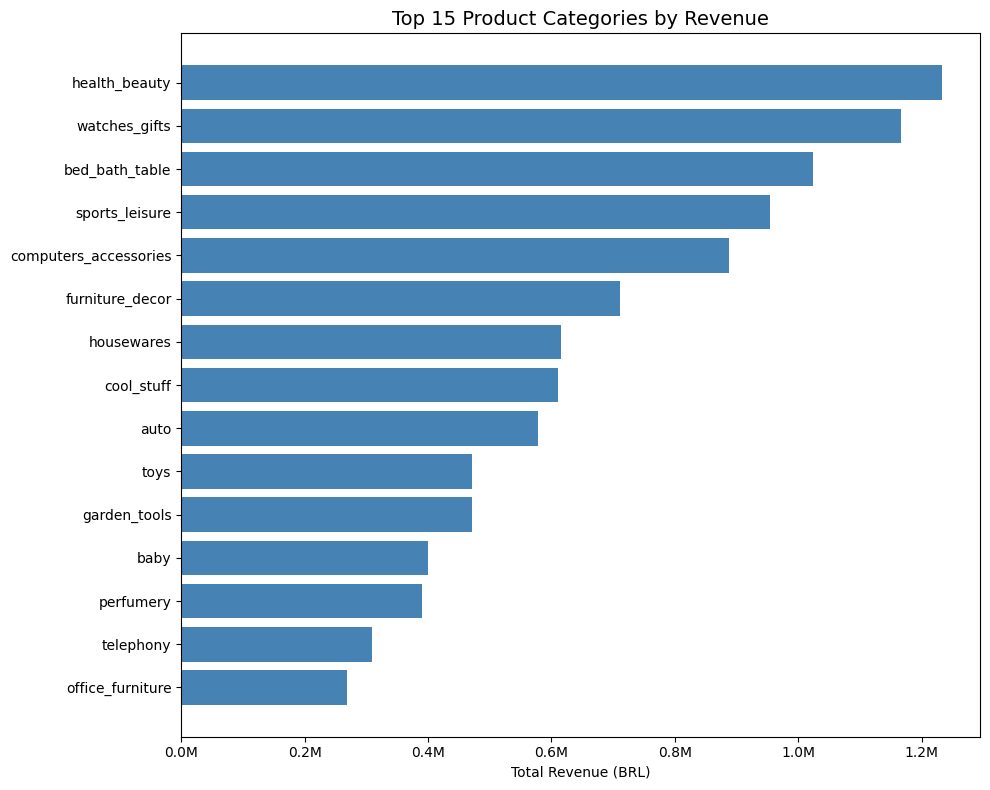

Chart saved.


In [10]:
fig, ax = plt.subplots(figsize=(10, 8))

bars = ax.barh(
    category_performance['product_category_name_english'][::-1],
    category_performance['total_revenue'][::-1],
    color='steelblue'
)

ax.set_xlabel('Total Revenue (BRL)')
ax.set_title('Top 15 Product Categories by Revenue', fontsize=14)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

plt.tight_layout()
plt.savefig('../exports/category_revenue.png', dpi=150)
plt.show()
print("Chart saved.")

In [11]:
category_share = pd.read_sql("""
    WITH category_revenue AS (
        SELECT
            product_category_name_english,
            ROUND(SUM(price), 2) AS total_revenue
        FROM master_orders
        GROUP BY product_category_name_english
    ),
    total AS (
        SELECT ROUND(SUM(price), 2) AS grand_total FROM master_orders
    )
    SELECT
        c.product_category_name_english,
        c.total_revenue,
        ROUND(c.total_revenue / t.grand_total * 100, 2) AS revenue_share_pct
    FROM category_revenue c, total t
    ORDER BY c.total_revenue DESC
    LIMIT 15
""", connection)

category_share

,product_category_name_english,total_revenue,revenue_share_pct
0,health_beauty,1232996.75,9.33
1,watches_gifts,1165898.98,8.82
2,bed_bath_table,1023434.76,7.74
3,sports_leisure,954673.55,7.22
4,computers_accessories,888613.62,6.72
5,furniture_decor,711927.69,5.39
6,housewares,615628.69,4.66
7,cool_stuff,610204.10,4.62
8,auto,578849.35,4.38
9,toys,471097.49,3.56


In [12]:
#This query is to understand what the median average review score is and use that value to identify hidden gems
review_dist = pd.read_sql("""
    SELECT
        product_category_name_english,
        COUNT(DISTINCT order_id)     AS total_orders,
        ROUND(AVG(review_score), 2)  AS avg_review_score
    FROM master_orders
    GROUP BY product_category_name_english
    HAVING total_orders BETWEEN 100 AND 1000
    ORDER BY avg_review_score DESC
""", connection)

print(f"Average review score across these categories: {review_dist['avg_review_score'].mean():.2f}")
print(f"Median: {review_dist['avg_review_score'].median():.2f}")
review_dist.head(10)

Average review score across these categories: 4.11
Median: 4.11


,product_category_name_english,total_orders,avg_review_score
0,books_general_interest,495,4.51
1,books_technical,256,4.39
2,food_drink,221,4.36
3,fashion_shoes,235,4.31
4,food,441,4.28
5,small_appliances,609,4.23
6,musical_instruments,611,4.23
7,home_appliances,747,4.23
8,computers,177,4.23
9,home_appliances_2,227,4.16


In [38]:
hidden_gems = pd.read_sql("""
    SELECT
        product_category_name_english,
        COUNT(DISTINCT order_id)     AS total_orders,
        ROUND(SUM(price), 2)         AS total_revenue,
        ROUND(AVG(review_score), 2)  AS avg_review_score
    FROM master_orders
    GROUP BY product_category_name_english
    HAVING total_orders BETWEEN 100 AND 1481
       AND avg_review_score >= 4.11
    ORDER BY avg_review_score DESC
""", connection)

hidden_gems

,product_category_name_english,total_orders,total_revenue,avg_review_score
0,books_general_interest,495,45256.25,4.51
1,books_technical,256,18702.23,4.39
2,food_drink,221,14942.88,4.36
3,luggage_accessories,1019,138701.63,4.35
4,fashion_shoes,235,23001.46,4.31
5,food,441,28731.15,4.28
6,small_appliances,609,182754.12,4.23
7,musical_instruments,611,184315.74,4.23
8,home_appliances,747,78832.48,4.23
9,computers,177,218684.14,4.23


## Key Insight: Hidden Gems — High Satisfaction, Growth Potential
- 17 categories qualify as hidden gems (100–1,481 orders, avg review ≥ 4.11)
- Threshold logic:
    * Lower bound 100 orders — minimum for review score reliability
    * Upper bound 1,481 orders — 75th percentile of category volume,
      excludes already-dominant categories
    * Review score ≥ 4.11 — median avg score across all categories

- Standout finding: computers (177 orders, 218K BRL revenue, 4.23 score)
  has the highest avg order value in the entire hidden gems list at ~1,235 BRL
  — a premium category with strong satisfaction and significant revenue upside

- High revenue hidden gems worth prioritizing:
    * musical_instruments: 184K BRL, 4.23 score
    * small_appliances: 182K BRL, 4.23 score
    * home_appliances: 78K BRL, 4.23 score

- Original hidden gems still hold: books_general_interest, books_technical, 
  food_drink — highest satisfaction scores (4.51, 4.39, 4.36) suggesting 
  lowest return/complaint rates in the dataset

- Recommendation: Two-tier growth strategy:
    * Invest in computers, musical_instruments, small_appliances 
      for high revenue upside
    * Invest in books and food categories for customer satisfaction 
      and loyalty building

In [39]:
category_performance.to_csv("../exports/category_performance.csv", index=False)
category_share.to_csv("../exports/category_share.csv", index=False)
hidden_gems.to_csv("../exports/hidden_gems.csv", index=False)

print("✓ Category analysis exported")

✓ Category analysis exported


In [15]:
delivery_status = pd.read_sql("""
    SELECT
        CASE WHEN is_late = 1 THEN 'Late' ELSE 'On Time' END AS delivery_status,
        COUNT(DISTINCT order_id)            AS total_orders,
        ROUND(AVG(review_score), 2)         AS avg_review_score,
        ROUND(AVG(actual_delivery_days), 1) AS avg_delivery_days
    FROM master_orders
    GROUP BY is_late
""", connection)

delivery_status

,delivery_status,total_orders,avg_review_score,avg_delivery_days
0,On Time,88644,4.22,10.4
1,Late,7825,2.60,30.9


In [16]:
delivery_buckets = pd.read_sql("""
    SELECT
        CASE
            WHEN actual_delivery_days <= 7  THEN '1. 0-7 days'
            WHEN actual_delivery_days <= 14 THEN '2. 8-14 days'
            WHEN actual_delivery_days <= 21 THEN '3. 15-21 days'
            WHEN actual_delivery_days <= 30 THEN '4. 22-30 days'
            ELSE                                 '5. 30+ days'
        END AS delivery_bucket,
        COUNT(DISTINCT order_id)            AS total_orders,
        ROUND(AVG(actual_delivery_days), 1) AS avg_delivery_days,
        ROUND(AVG(review_score), 2)         AS avg_review_score,
        ROUND(AVG(freight_value), 2)        AS avg_freight_cost
    FROM master_orders
    GROUP BY delivery_bucket
    ORDER BY delivery_bucket
""", connection)

delivery_buckets

,delivery_bucket,total_orders,avg_delivery_days,avg_review_score,avg_freight_cost
0,1. 0-7 days,33696,4.8,4.33,15.48
1,2. 8-14 days,36397,10.6,4.21,20.60
2,3. 15-21 days,15369,17.5,4.03,23.55
3,4. 22-30 days,6891,25.1,3.45,26.21
4,5. 30+ days,4116,42.3,2.25,27.58


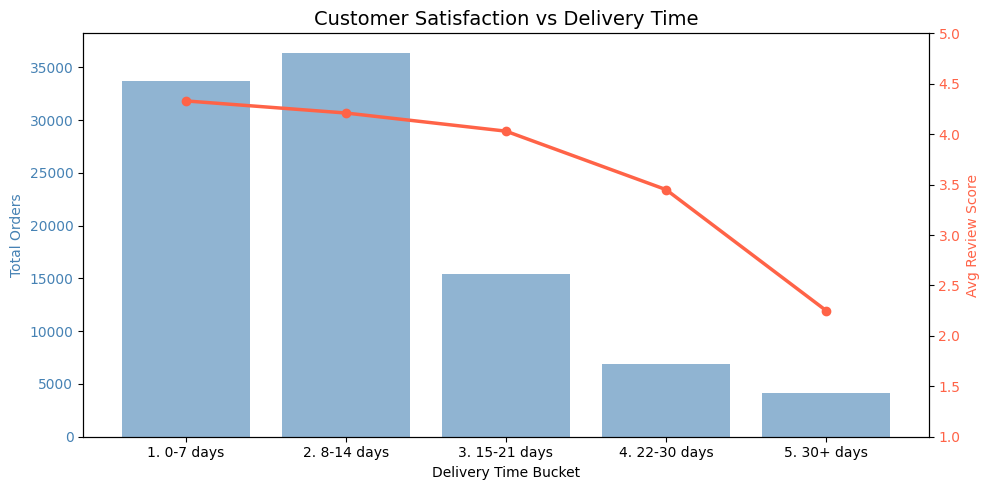

Chart saved.


In [17]:
fig, ax1 = plt.subplots(figsize=(10, 5))

color1 = 'steelblue'
color2 = 'tomato'

ax1.bar(delivery_buckets['delivery_bucket'],
        delivery_buckets['total_orders'],
        color=color1, alpha=0.6, label='Total Orders')
ax1.set_xlabel('Delivery Time Bucket')
ax1.set_ylabel('Total Orders', color=color1)
ax1.tick_params(axis='y', labelcolor=color1)

ax2 = ax1.twinx()
ax2.plot(delivery_buckets['delivery_bucket'],
         delivery_buckets['avg_review_score'],
         color=color2, marker='o', linewidth=2.5, label='Avg Review Score')
ax2.set_ylabel('Avg Review Score', color=color2)
ax2.tick_params(axis='y', labelcolor=color2)
ax2.set_ylim(1, 5)

plt.title('Customer Satisfaction vs Delivery Time', fontsize=14)
fig.tight_layout()
plt.savefig('../exports/delivery_vs_satisfaction.png', dpi=150)
plt.show()
print("Chart saved.")

In [35]:
state_delivery = pd.read_sql("""
    SELECT
        customer_state,
        COUNT(DISTINCT order_id)            AS total_orders,
        ROUND(AVG(actual_delivery_days), 1) AS avg_delivery_days,
        ROUND(AVG(freight_value), 2)        AS avg_freight_cost,
        ROUND(AVG(review_score), 2)         AS avg_review_score,
        COUNT(DISTINCT CASE WHEN is_late = 1 
          THEN order_id END)                        AS late_orders,
        ROUND(COUNT(DISTINCT CASE WHEN is_late = 1 
          THEN order_id END) * 100.0 / 
          COUNT(DISTINCT order_id), 1)              AS late_pct
FROM master_orders
GROUP BY customer_state
ORDER BY avg_delivery_days DESC;
""", connection)

state_delivery

,customer_state,total_orders,avg_delivery_days,avg_freight_cost,avg_review_score,late_orders,late_pct
0,RR,41,27.8,43.09,3.89,5,12.2
1,AP,67,27.8,34.16,4.27,3,4.5
2,AM,145,26.0,33.31,4.12,6,4.1
3,AL,397,24.0,35.87,3.84,95,23.9
4,PA,946,23.3,35.63,3.86,117,12.4
5,MA,717,21.2,38.49,3.77,141,19.7
6,SE,335,21.0,36.57,3.90,51,15.2
7,CE,1279,20.5,32.73,3.88,196,15.3
8,AC,80,20.3,40.05,4.13,3,3.8
9,PB,517,20.1,43.09,4.05,57,11.0


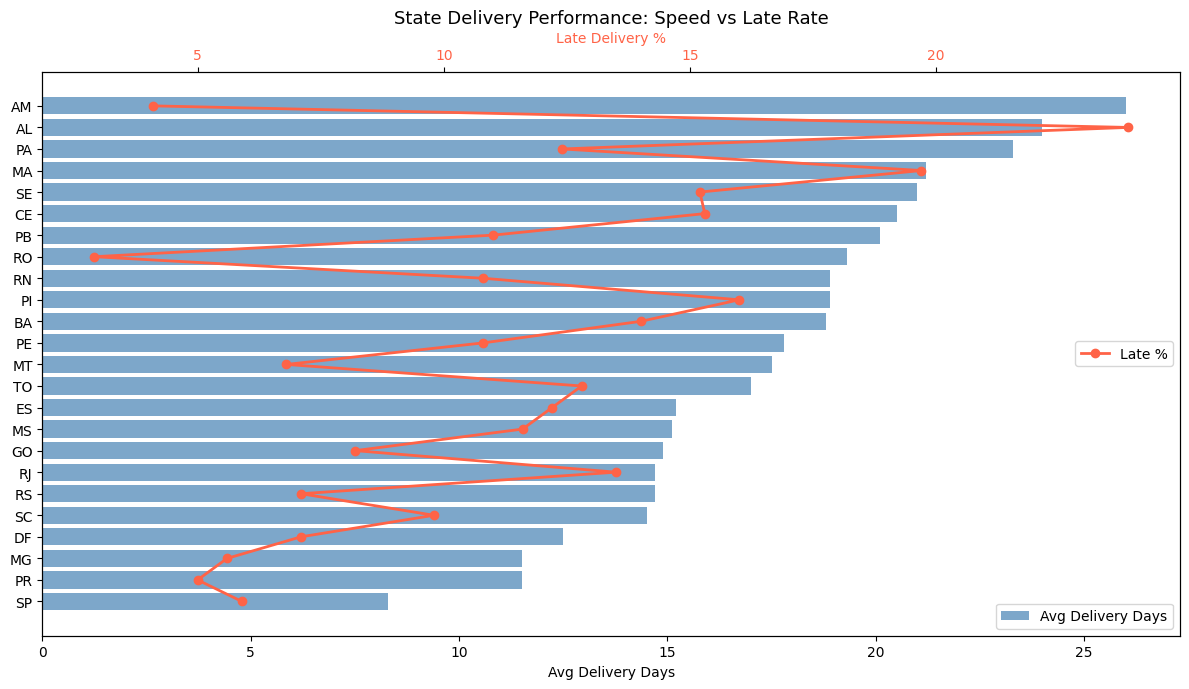

Chart saved.


In [36]:
# Filter states with meaningful volume
state_filtered = state_delivery[state_delivery['total_orders'] >= 100].copy()

fig, ax1 = plt.subplots(figsize=(12, 7))

# Sort by avg delivery days
state_filtered = state_filtered.sort_values('avg_delivery_days', ascending=True)

color1 = 'steelblue'
color2 = 'tomato'

bars = ax1.barh(state_filtered['customer_state'],
                state_filtered['avg_delivery_days'],
                color=color1, alpha=0.7, label='Avg Delivery Days')
ax1.set_xlabel('Avg Delivery Days')
ax1.set_title('State Delivery Performance: Speed vs Late Rate', fontsize=13)

ax2 = ax1.twiny()
ax2.plot(state_filtered['late_pct'],
         state_filtered['customer_state'],
         color=color2, marker='o', linewidth=2, label='Late %')
ax2.set_xlabel('Late Delivery %', color=color2)
ax2.tick_params(axis='x', labelcolor=color2)

ax1.legend(loc='lower right')
ax2.legend(loc='center right')

plt.tight_layout()
plt.savefig('../exports/state_delivery_performance.png', dpi=150)
plt.show()
print("Chart saved.")

In [37]:
delivery_status.to_csv("../exports/delivery_status.csv", index=False)
delivery_buckets.to_csv("../exports/delivery_buckets.csv", index=False)
state_delivery.to_csv("../exports/state_delivery.csv", index=False)

print("✓ Delivery analysis exported")

✓ Delivery analysis exported


In [28]:
rfm = pd.read_sql("""
    WITH rfm_base AS (
        SELECT
            customer_unique_id,
            MAX(DATE(order_purchase_timestamp))            AS last_order_date,
            COUNT(DISTINCT order_id)                       AS frequency,
            ROUND(SUM(price + freight_value), 2)           AS monetary,
            JULIANDAY('2018-10-18') -
            JULIANDAY(MAX(DATE(order_purchase_timestamp))) AS recency_days
        FROM master_orders
        GROUP BY customer_unique_id
    ),
    rfm_scores AS (
        SELECT
            customer_unique_id,
            last_order_date,
            recency_days,
            frequency,
            monetary,
            NTILE(5) OVER (ORDER BY recency_days DESC) AS r_score,
            NTILE(5) OVER (ORDER BY monetary ASC)      AS m_score
        FROM rfm_base
    )
    SELECT
        customer_unique_id,
        last_order_date,
        recency_days,
        frequency,
        monetary,
        r_score,
        m_score,
        ROUND((r_score + m_score) * 1.0 / 2, 2) AS rm_avg,
        CASE
            WHEN r_score >= 4 AND m_score >= 4 THEN 'Champions'
            WHEN r_score >= 4 AND m_score BETWEEN 2 AND 3 THEN 'Promising'
            WHEN r_score >= 4 AND m_score = 1 THEN 'New Low Spenders'
            WHEN r_score = 3 AND m_score >= 3 THEN 'Loyal Customers'
            WHEN r_score = 3 AND m_score <= 2 THEN 'Potential Loyalists'
            WHEN r_score = 2 AND m_score >= 3 THEN 'At Risk'
            WHEN r_score = 2 AND m_score <= 2 THEN 'Slipping Away'
            WHEN r_score = 1 AND m_score >= 3 THEN 'High Value Lost'
            WHEN r_score = 1 AND m_score <= 2 THEN 'Lost'
        END AS segment
    FROM rfm_scores
    ORDER BY rm_avg DESC
""", connection)

print(f"Total customers segmented: {len(rfm)}")
print(f"Null segments: {rfm['segment'].isnull().sum()}")
rfm.head(10)

Total customers segmented: 93349
Null segments: 0


,customer_unique_id,last_order_date,recency_days,frequency,monetary,r_score,m_score,rm_avg,segment
0,4b1544b0977e0988f822c138bfc549c0,2018-05-29,142.0,1,317.40,5,5,5.0,Champions
1,15ce72bd39132d109676e7018ef9a314,2018-05-29,142.0,1,322.80,5,5,5.0,Champions
2,1d595351d8b1153bc10dfe9870cc91f7,2018-05-29,142.0,1,325.01,5,5,5.0,Champions
3,a9bb62880a097f2ec9ac056fe55be2fc,2018-05-29,142.0,1,334.62,5,5,5.0,Champions
4,d65921a138c59000aff343f8c991b896,2018-05-29,142.0,2,343.57,5,5,5.0,Champions
5,3be8da680007e60e431a405c835d8272,2018-05-29,142.0,1,355.32,5,5,5.0,Champions
6,52bb1f6c53b3cac6719677e7e8957bc8,2018-05-29,142.0,1,369.32,5,5,5.0,Champions
7,814bce430ba8d69ffd9fe2abba84fd55,2018-05-29,142.0,1,411.16,5,5,5.0,Champions
8,46d42c60487c64480765a312ee6172c8,2018-05-29,142.0,1,421.38,5,5,5.0,Champions
9,d39ca7f15bf72b7010ec9f965ab138e6,2018-05-29,142.0,1,503.28,5,5,5.0,Champions


In [29]:
segment_summary = rfm.groupby('segment').agg(
    total_customers=('customer_unique_id', 'count'),
    avg_recency_days=('recency_days', 'mean'),
    avg_monetary=('monetary', 'mean'),
    total_revenue=('monetary', 'sum')
).round(2).reset_index()

segment_summary = segment_summary.sort_values('total_revenue', ascending=False)
print(segment_summary)

               segment  total_customers  avg_recency_days  avg_monetary  \
1            Champions            15409            140.78        307.20   
0              At Risk            11072            365.32        243.53   
2      High Value Lost            10821            522.69        240.28   
4      Loyal Customers            11149            269.87        225.42   
7            Promising            14622            139.32         89.91   
3                 Lost             7849            522.88         55.45   
8        Slipping Away             7598            365.61         56.14   
6  Potential Loyalists             7521            268.64         54.42   
5     New Low Spenders             7308            139.25         39.56   

   total_revenue  
1     4733693.30  
0     2696387.20  
2     2600048.09  
4     2513259.87  
7     1314659.11  
3      435191.33  
8      426578.28  
6      409295.31  
5      289138.88  


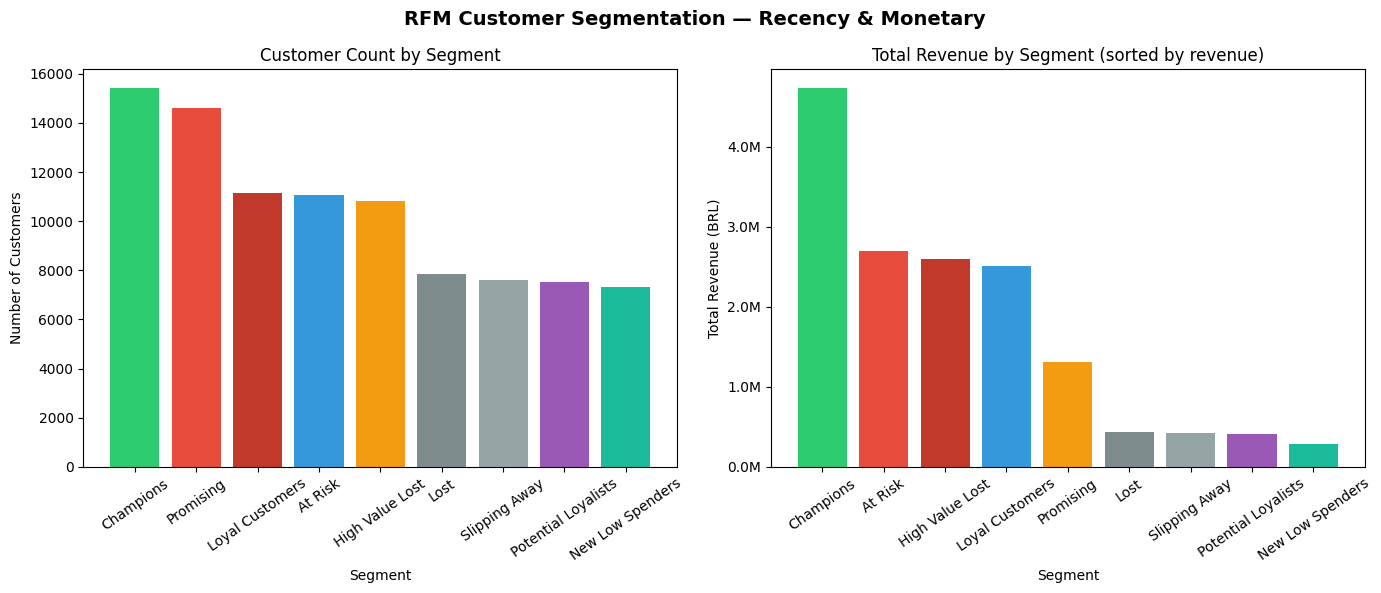

Chart saved.


In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors = ['#2ecc71','#e74c3c','#c0392b','#3498db',
          '#f39c12','#7f8c8d','#95a5a6','#9b59b6','#1abc9c']

segment_summary_sorted_count = segment_summary.sort_values(
    'total_customers', ascending=False)

# Left: Customer count per segment
axes[0].bar(segment_summary_sorted_count['segment'],
            segment_summary_sorted_count['total_customers'],
            color=colors)
axes[0].set_title('Customer Count by Segment')
axes[0].set_xlabel('Segment')
axes[0].set_ylabel('Number of Customers')
axes[0].tick_params(axis='x', rotation=35)

# Right: Revenue per segment
axes[1].bar(segment_summary['segment'],
            segment_summary['total_revenue'],
            color=colors)
axes[1].set_title('Total Revenue by Segment (sorted by revenue)')
axes[1].set_xlabel('Segment')
axes[1].set_ylabel('Total Revenue (BRL)')
axes[1].tick_params(axis='x', rotation=35)
axes[1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

plt.suptitle('RFM Customer Segmentation — Recency & Monetary',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../exports/rfm_segments.png', dpi=150)
plt.show()
print("Chart saved.")

In [31]:
rfm.to_csv("../exports/rfm_customers.csv", index=False)
segment_summary.to_csv("../exports/rfm_segment_summary.csv", index=False)
print("✓ RFM analysis exported")

✓ RFM analysis exported


## Key Insight: RFM Customer Segmentation
- 'Frequency' dropped as a segmentation dimension — 97% of customers ordered only once, making it statistically meaningless as a differentiator
- Segmentation based on Recency and Monetary using NTILE(5) quintile scoring
- Champions (15,409 customers) are the largest segment with the highest avg spend at 307 BRL — Olist's most valuable and recently active customer group
- Critical finding: At Risk + High Value Lost = 21,893 customers and 5.3M BRL in revenue from disengaged or lost customers
- Recommendation: Priority retention campaign targeting At Risk segment (365 avg recency days, still recoverable) before they move to High Value Lost
- Promising segment (14,622 customers, 139 avg recency days) represents the best upsell opportunity — recently active but low spend

In [32]:
cat_orders = pd.read_sql("""
    SELECT
        product_category_name_english,
        COUNT(DISTINCT order_id) AS total_orders
    FROM master_orders
    GROUP BY product_category_name_english
    ORDER BY total_orders DESC
""", connection)

print(cat_orders.describe())
print(f"\nCategories with 100-1000 orders: {len(cat_orders[(cat_orders['total_orders']>=100) & (cat_orders['total_orders']<=1000)])}")
print(f"Categories with <100 orders: {len(cat_orders[cat_orders['total_orders']<100])}")
print(f"Categories with >1000 orders: {len(cat_orders[cat_orders['total_orders']>1000])}")

       total_orders
count     72.000000
mean    1350.930556
std     2208.856414
min        2.000000
25%       87.250000
50%      244.000000
75%     1481.000000
max     9272.000000

Categories with 100-1000 orders: 30
Categories with <100 orders: 20
Categories with >1000 orders: 22


In [40]:
seller_scorecard = pd.read_sql("""
    SELECT
        seller_id,
        seller_city,
        seller_state,
        COUNT(DISTINCT order_id)                        AS total_orders,
        ROUND(SUM(price), 2)                            AS total_revenue,
        ROUND(AVG(price), 2)                            AS avg_item_price,
        ROUND(AVG(review_score), 2)                     AS avg_review_score,
        COUNT(DISTINCT CASE WHEN is_late = 1
              THEN order_id END)                        AS late_orders,
        ROUND(COUNT(DISTINCT CASE WHEN is_late = 1
              THEN order_id END) * 100.0 /
              COUNT(DISTINCT order_id), 1)              AS late_pct,
        ROUND(AVG(actual_delivery_days), 1)             AS avg_delivery_days
    FROM master_orders
    GROUP BY seller_id, seller_city, seller_state
    HAVING total_orders >= 30
    ORDER BY total_revenue DESC
""", connection)

print(f"Sellers with 30+ orders: {len(seller_scorecard)}")
seller_scorecard.head(10)

Sellers with 30+ orders: 627


,seller_id,seller_city,seller_state,total_orders,total_revenue,avg_item_price,avg_review_score,late_orders,late_pct,avg_delivery_days
0,4869f7a5dfa277a7dca6462dcf3b52b2,guariba,SP,1124,226987.93,197.72,4.15,130,11.6,14.5
1,53243585a1d6dc2643021fd1853d8905,lauro de freitas,BA,348,217940.44,544.85,4.13,15,4.3,12.9
2,4a3ca9315b744ce9f8e9374361493884,ibitinga,SP,1772,196882.12,101.02,3.84,195,11.0,13.9
3,fa1c13f2614d7b5c4749cbc52fecda94,sumare,SP,578,190917.14,329.74,4.38,59,10.2,12.8
4,7c67e1448b00f6e969d365cea6b010ab,itaquaquecetuba,SP,973,186570.05,137.69,3.36,98,10.1,21.9
5,7e93a43ef30c4f03f38b393420bc753a,barueri,SP,319,165981.49,515.47,4.37,18,5.6,10.8
6,da8622b14eb17ae2831f4ac5b9dab84a,piracicaba,SP,1311,159816.87,103.24,4.08,100,7.6,10.7
7,7a67c85e85bb2ce8582c35f2203ad736,sao paulo,SP,1145,139658.69,120.92,4.27,68,5.9,10.7
8,1025f0e2d44d7041d6cf58b6550e0bfa,sao paulo,SP,910,138208.56,97.33,3.89,92,10.1,11.6
9,955fee9216a65b617aa5c0531780ce60,sao paulo,SP,1261,131836.71,89.56,4.09,98,7.8,10.3


In [41]:
seller_segments = pd.read_sql("""
    WITH seller_stats AS (
        SELECT
            seller_id,
            seller_state,
            COUNT(DISTINCT order_id)                    AS total_orders,
            ROUND(SUM(price), 2)                        AS total_revenue,
            ROUND(AVG(review_score), 2)                 AS avg_review_score,
            ROUND(COUNT(DISTINCT CASE WHEN is_late = 1
                  THEN order_id END) * 100.0 /
                  COUNT(DISTINCT order_id), 1)          AS late_pct
        FROM master_orders
        GROUP BY seller_id, seller_state
        HAVING total_orders >= 30
    )
    SELECT
        seller_id,
        seller_state,
        total_orders,
        total_revenue,
        avg_review_score,
        late_pct,
        CASE
            WHEN avg_review_score >= 4.0 AND late_pct <= 8.1 THEN 'Top Performer'
            WHEN avg_review_score >= 4.0 AND late_pct > 8.1  THEN 'Good Quality Late Delivery'
            WHEN avg_review_score < 4.0  AND late_pct <= 8.1 THEN 'Low Satisfaction On Time'
            WHEN avg_review_score < 4.0  AND late_pct > 8.1  THEN 'At Risk'
        END AS seller_segment
    FROM seller_stats
    ORDER BY total_revenue DESC
""", connection)

print(seller_segments['seller_segment'].value_counts())
seller_segments.head(10)

seller_segment
Top Performer                 304
Good Quality Late Delivery    132
At Risk                       122
Low Satisfaction On Time       69
Name: count, dtype: int64


,seller_id,seller_state,total_orders,total_revenue,avg_review_score,late_pct,seller_segment
0,4869f7a5dfa277a7dca6462dcf3b52b2,SP,1124,226987.93,4.15,11.6,Good Quality Late Delivery
1,53243585a1d6dc2643021fd1853d8905,BA,348,217940.44,4.13,4.3,Top Performer
2,4a3ca9315b744ce9f8e9374361493884,SP,1772,196882.12,3.84,11.0,At Risk
3,fa1c13f2614d7b5c4749cbc52fecda94,SP,578,190917.14,4.38,10.2,Good Quality Late Delivery
4,7c67e1448b00f6e969d365cea6b010ab,SP,973,186570.05,3.36,10.1,At Risk
5,7e93a43ef30c4f03f38b393420bc753a,SP,319,165981.49,4.37,5.6,Top Performer
6,da8622b14eb17ae2831f4ac5b9dab84a,SP,1311,159816.87,4.08,7.6,Top Performer
7,7a67c85e85bb2ce8582c35f2203ad736,SP,1145,139658.69,4.27,5.9,Top Performer
8,1025f0e2d44d7041d6cf58b6550e0bfa,SP,910,138208.56,3.89,10.1,At Risk
9,955fee9216a65b617aa5c0531780ce60,SP,1261,131836.71,4.09,7.8,Top Performer


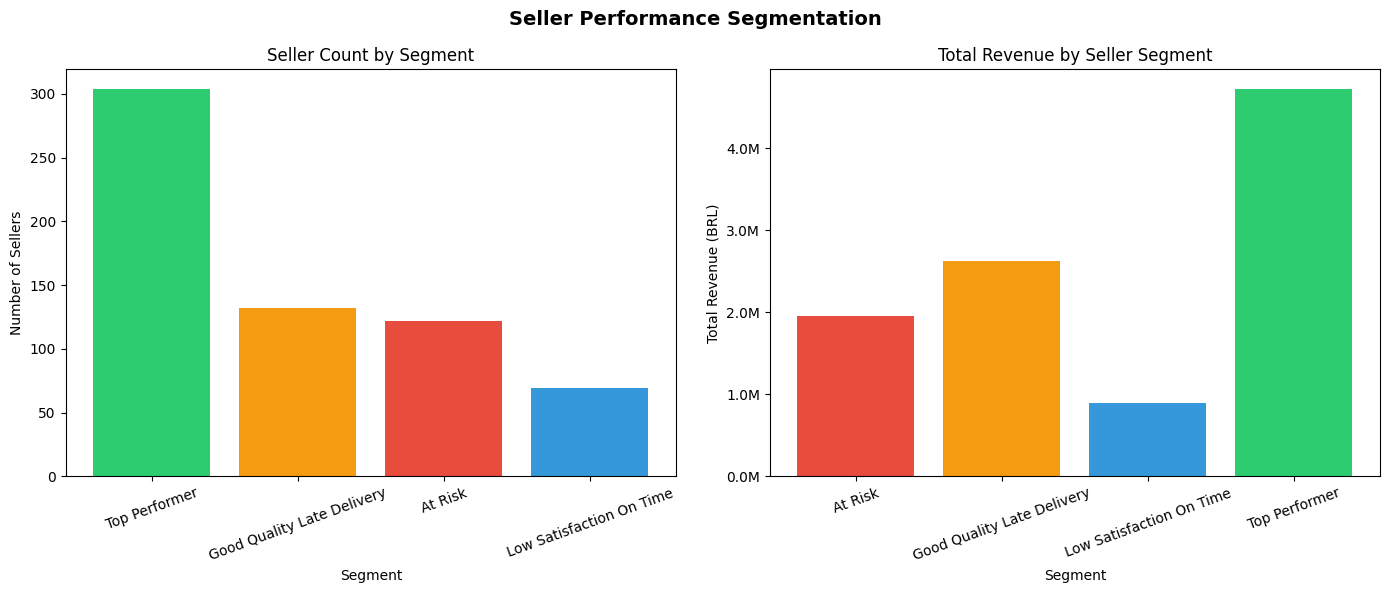

Chart saved.


In [42]:
segment_counts = seller_segments['seller_segment'].value_counts()

colors = {
    'Top Performer': '#2ecc71',
    'Good Quality Late Delivery': '#f39c12',
    'Low Satisfaction On Time': '#3498db',
    'At Risk': '#e74c3c'
}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: Seller count per segment
axes[0].bar(segment_counts.index,
            segment_counts.values,
            color=[colors[s] for s in segment_counts.index])
axes[0].set_title('Seller Count by Segment')
axes[0].set_xlabel('Segment')
axes[0].set_ylabel('Number of Sellers')
axes[0].tick_params(axis='x', rotation=20)

# Right: Revenue per segment
segment_revenue = seller_segments.groupby('seller_segment')['total_revenue'].sum()
axes[1].bar(segment_revenue.index,
            segment_revenue.values,
            color=[colors[s] for s in segment_revenue.index])
axes[1].set_title('Total Revenue by Seller Segment')
axes[1].set_xlabel('Segment')
axes[1].set_ylabel('Total Revenue (BRL)')
axes[1].tick_params(axis='x', rotation=20)
axes[1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

plt.suptitle('Seller Performance Segmentation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../exports/seller_segments.png', dpi=150)
plt.show()
print("Chart saved.")

In [43]:
seller_by_state = pd.read_sql("""
    SELECT
        seller_state,
        COUNT(DISTINCT seller_id)                       AS total_sellers,
        ROUND(SUM(price), 2)                            AS total_revenue,
        ROUND(AVG(review_score), 2)                     AS avg_review_score,
        ROUND(COUNT(DISTINCT CASE WHEN is_late = 1
              THEN order_id END) * 100.0 /
              COUNT(DISTINCT order_id), 1)              AS late_pct,
        ROUND(AVG(actual_delivery_days), 1)             AS avg_delivery_days
    FROM master_orders
    GROUP BY seller_state
    ORDER BY total_revenue DESC
""", connection)

seller_by_state.head(10)

,seller_state,total_sellers,total_revenue,avg_review_score,late_pct,avg_delivery_days
0,SP,1769,8508540.28,4.06,8.7,11.8
1,PR,335,1231962.02,4.13,6.4,12.9
2,MG,236,977588.31,4.17,5.6,12.3
3,RJ,163,820611.59,4.17,8.4,11.6
4,SC,184,613591.65,4.14,6.0,13.1
5,RS,125,373412.08,4.26,4.3,11.1
6,BA,18,277925.51,4.16,5.8,13.4
7,DF,30,94840.31,4.07,6.1,12.1
8,PE,9,91164.15,4.15,4.5,12.5
9,GO,39,64806.59,4.31,4.0,12.4


## Key Insight: Seller Performance
- 627 sellers qualify with 30+ orders (statistically meaningful sample)
- Segment thresholds: review_score ≥ 4.0 (intuitive midpoint on 1-5 scale),
  late_pct ≤ 8.1% (platform average — sellers benchmarked against 
  their own platform, not arbitrary numbers)
- 49% of sellers are Top Performers — healthy platform quality overall
- 122 At Risk sellers (20%) have both low satisfaction AND high late rates —
  priority candidates for seller intervention or removal
- SP dominates revenue (8.5M BRL, 1,769 sellers) but has the highest 
  late rate (8.7%) among major states — scale is creating delivery strain
- RS and GO are standout states: highest review scores (4.26, 4.31) 
  and lowest late rates (4.3%, 4.0%) despite lower volumes — 
  these sellers punch above their weight on quality
- Recommendation: Replicate operational practices of RS and GO sellers
  in SP to reduce late delivery rate at scale

In [47]:
conn = sqlite3.connect(db_path)

checks = {}

# Total delivered orders (distinct — not rows)
checks['total_orders'] = pd.read_sql("""
    SELECT COUNT(DISTINCT order_id) AS val FROM master_orders
""", conn).iloc[0,0]

# Total revenue
checks['total_revenue'] = pd.read_sql("""
    SELECT ROUND(SUM(price + freight_value), 2) AS val FROM master_orders
""", conn).iloc[0,0]

# Average order value (revenue / orders)
checks['avg_order_value'] = round(checks['total_revenue'] / checks['total_orders'], 2)

# Average delivery days
checks['avg_delivery_days'] = pd.read_sql("""
    SELECT ROUND(AVG(actual_delivery_days), 1) AS val FROM master_orders
""", conn).iloc[0,0]

# Late delivery rate
checks['late_rate_pct'] = pd.read_sql("""
    SELECT ROUND(COUNT(DISTINCT CASE WHEN is_late = 1 
           THEN order_id END) * 100.0 / 
           COUNT(DISTINCT order_id), 1) AS val
    FROM master_orders
""", conn).iloc[0,0]

# Total unique customers
checks['total_customers'] = pd.read_sql("""
    SELECT COUNT(DISTINCT customer_unique_id) AS val FROM master_orders
""", conn).iloc[0,0]

# Total qualifying sellers
checks['qualifying_sellers'] = pd.read_sql("""
    SELECT COUNT(*) AS val FROM (
        SELECT seller_id
        FROM master_orders
        GROUP BY seller_id
        HAVING COUNT(DISTINCT order_id) >= 30
    )
""", conn).iloc[0,0]

# Revenue growth 2017 to 2018
rev_by_year = pd.read_sql("""
    SELECT order_year, 
           ROUND(SUM(price + freight_value), 2) AS revenue
    FROM master_orders
    GROUP BY order_year
""", conn)
rev_2017 = rev_by_year.loc[rev_by_year['order_year']==2017, 'revenue'].values[0]
rev_2018 = rev_by_year.loc[rev_by_year['order_year']==2018, 'revenue'].values[0]
checks['revenue_growth_pct'] = round((rev_2018 - rev_2017) / rev_2017 * 100, 1)

conn.close()

for k, v in checks.items():
    print(f"{k}: {v}")

total_orders: 96469
total_revenue: 15418251.37
avg_order_value: 159.83
avg_delivery_days: 12.0
late_rate_pct: 8.1
total_customers: 93349
qualifying_sellers: 627
revenue_growth_pct: 22.1


In [ ]:
conn = sqlite3.connect(db_path)

top3_share = pd.read_sql("""
    WITH category_rev AS (
        SELECT
            product_category_name_english,
            ROUND(SUM(price), 2) AS total_revenue
        FROM master_orders
        GROUP BY product_category_name_english
        ORDER BY total_revenue DESC
        LIMIT 3
    ),
    total AS (
        SELECT ROUND(SUM(price), 2) AS grand_total 
        FROM master_orders
    )
    SELECT
        ROUND(SUM(c.total_revenue) / t.grand_total * 100, 1) AS top3_share_pct
    FROM category_rev c, total t
""", conn)

conn.close()
print(top3_share)

   top3_share_pct
0            25.9


In [4]:
connection = sqlite3.connect(db_path)

payment_analysis = pd.read_sql("""
    SELECT
        payment_type,
        COUNT(DISTINCT order_id)             AS total_orders,
        ROUND(SUM(total_payment), 2)         AS total_revenue,
        ROUND(AVG(total_payment), 2)         AS avg_payment_value,
        ROUND(COUNT(DISTINCT order_id) * 100.0 /
              SUM(COUNT(DISTINCT order_id)) 
              OVER(), 1)                     AS order_share_pct
    FROM master_orders
    GROUP BY payment_type
    ORDER BY total_orders DESC
""", connection)

payment_analysis.to_csv("../exports/payment_analysis.csv", index=False)
connection.close()
print(payment_analysis)

  payment_type  total_orders  total_revenue  avg_payment_value  \
0  credit_card         73213    15210566.95             182.50   
1       boleto         19191     3943080.78             176.33   
2      voucher          2582      374810.52             132.49   
3   debit_card          1483      246323.27             149.20   

   order_share_pct  
0             75.9  
1             19.9  
2              2.7  
3              1.5  


In [45]:
seller_scorecard.to_csv("../exports/seller_scorecard.csv", index=False)
seller_segments.to_csv("../exports/seller_segments.csv", index=False)
seller_by_state.to_csv("../exports/seller_by_state.csv", index=False)

connection.close()
print("✓ Seller analysis exported")
print("✓ Connection closed")
print("\n✓ All 5 SQL analyses complete")

✓ Seller analysis exported
✓ Connection closed

✓ All 5 SQL analyses complete
